<a href="https://colab.research.google.com/github/Meghan1432md/ML-lab/blob/main/ML_ORANGE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset (1).xlsx
Original dataset size: 13611 rows
Dataset size after filtering to 3 classes: 7501 rows


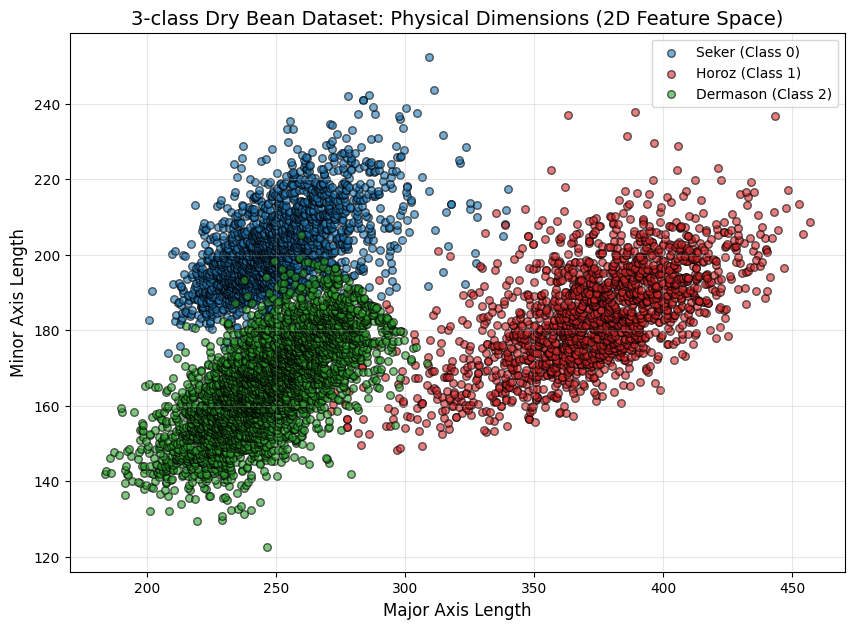

Train size: 5250 // Val size: 1125 // Test size: 1126


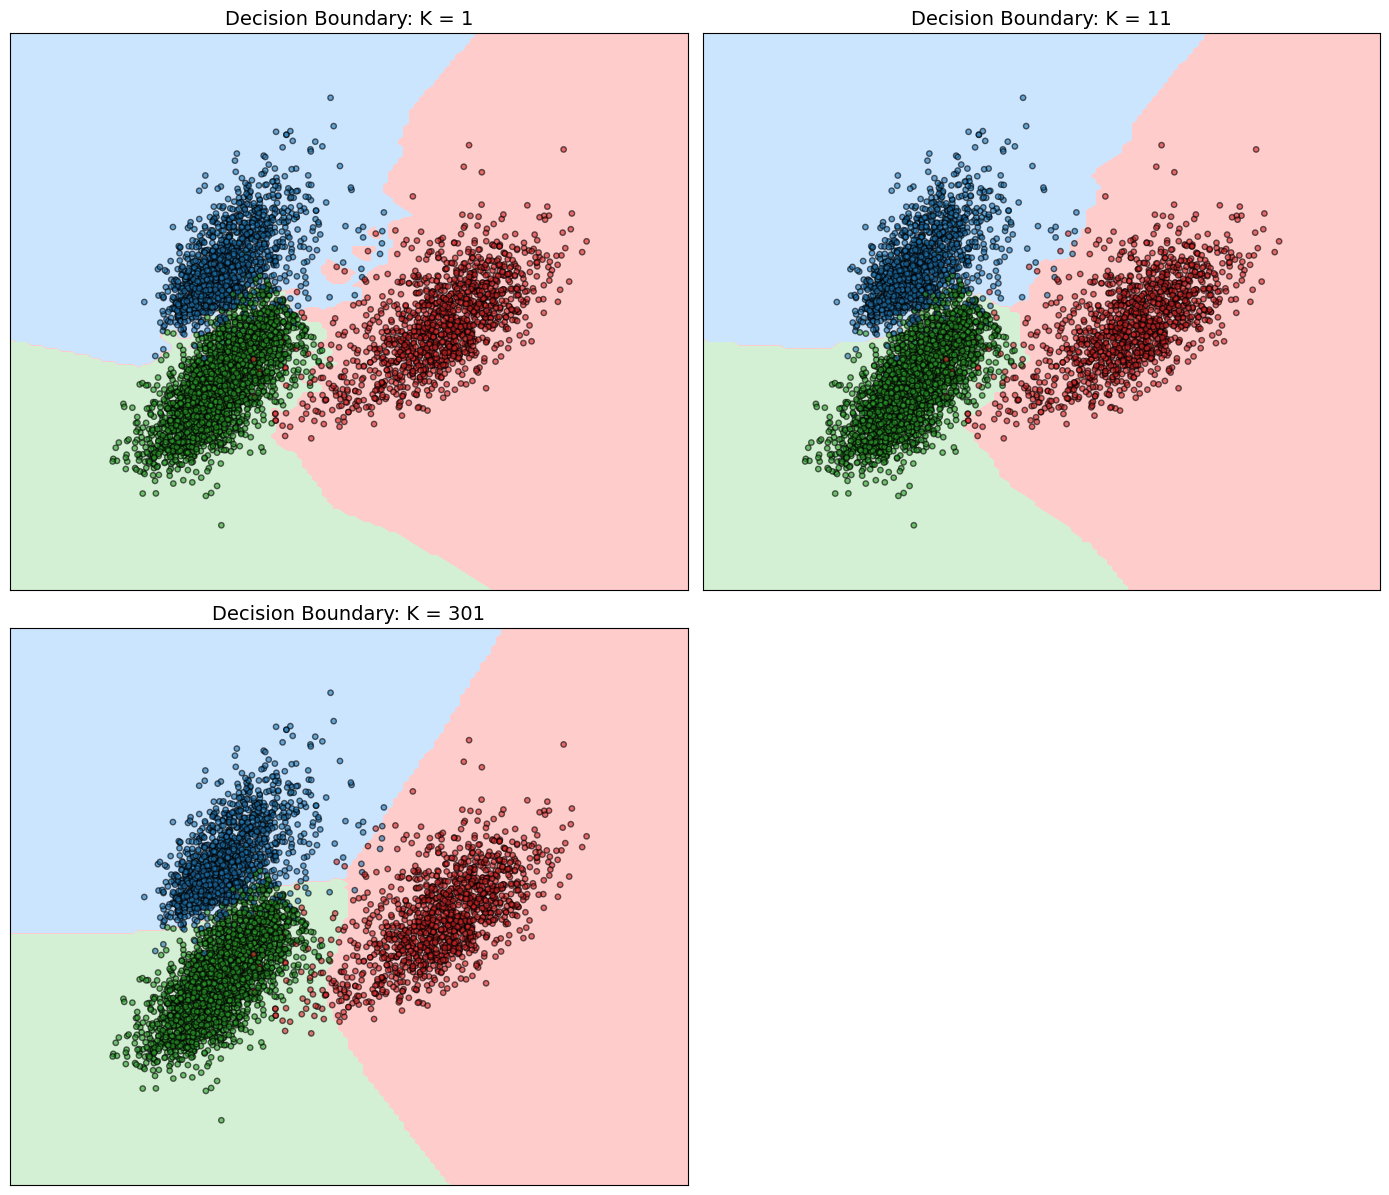


Optimal K value for the dataset 11


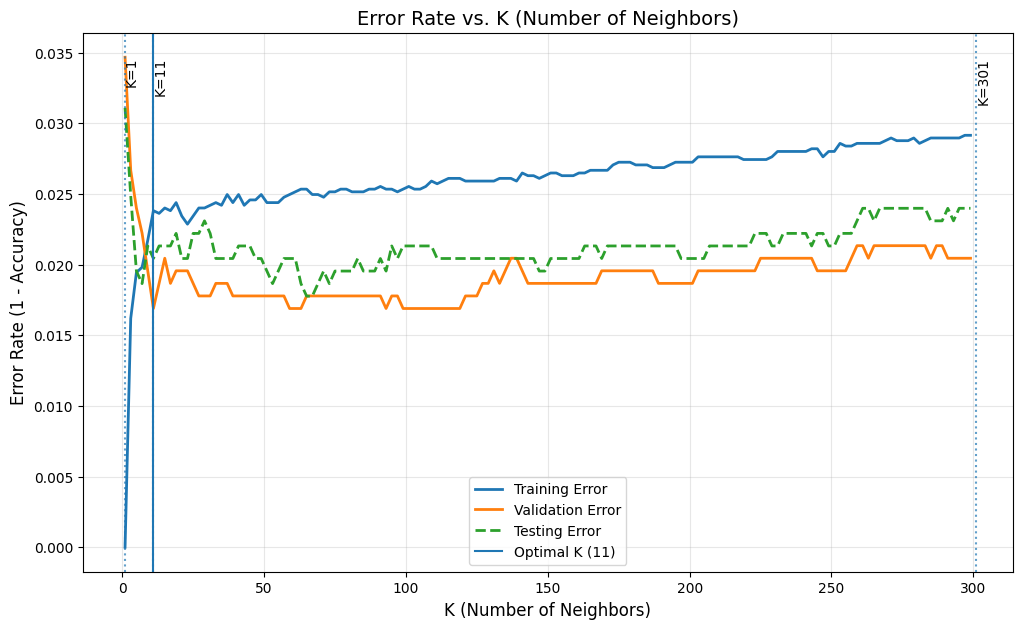


Test Accuracy = 0.9795737122557726
Test Accuracy Percentage =  97.95737122557726 %

Confusion Matrix:
 [[297   1   6]
 [  1 285   4]
 [ 10   1 521]]


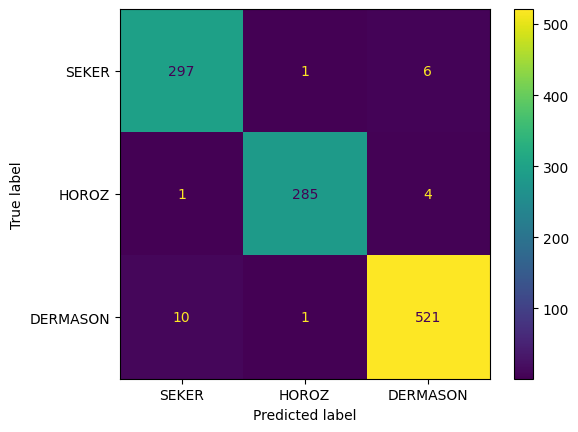


Classification Report

              precision    recall  f1-score   support

       SEKER       0.96      0.98      0.97       304
       HOROZ       0.99      0.98      0.99       290
    DERMASON       0.98      0.98      0.98       532

    accuracy                           0.98      1126
   macro avg       0.98      0.98      0.98      1126
weighted avg       0.98      0.98      0.98      1126



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ==========================================
# PART 1: DATA LOADING & VISUALIZATION
# ==========================================

#Load Dry_Bean_Dataset.xlsx
from google.colab import files
uploaded = files.upload()  # Opens a file picker
df = pd.read_excel('Dry_Bean_Dataset.xlsx')

# OG dataset size
print(f"Original dataset size: {len(df)} rows")

# Clean the 'Class' column by removing hidden spaces and making it UPPERCASE
# This prevents 0-row filtering errors due to messy raw data strings

df['Class'] = df['Class'].astype(str).str.strip().str.upper()

# The original dataset has 7 classes. We filter it down to exactly 3 classes

df = df[df['Class'].isin(['SEKER', 'HOROZ', 'DERMASON'])]

print(f"Dataset size after filtering to 3 classes: {len(df)} rows")

# Map the 3 chosen species to integers (0, 1, 2)
class_map = {'SEKER': 0, 'HOROZ': 1, 'DERMASON': 2}
df['class_encoded'] = df['Class'].map(class_map)

# We extract two physical dimensions for the 2D spatial map
# Feature 1: MajorAxisLength (Length of the bean)
# Feature 2: MinorAxisLength (Width of the bean)

X = df[['MajorAxisLength', 'MinorAxisLength']].values
y = df['class_encoded'].values

# Plotting the raw dataset
plt.figure(figsize=(10, 7))

classes = ['Seker (Class 0)', 'Horoz (Class 1)', 'Dermason (Class 2)']
colors = ['#1f77b4', '#d62728', '#2ca02c']

for i in range(3):
    plt.scatter(
        X[y == i, 0], X[y == i, 1],
        c=colors[i], label=classes[i],
        alpha=0.6, edgecolors='k', s=30
    )

plt.title('3-class Dry Bean Dataset: Physical Dimensions (2D Feature Space)', fontsize=14)
plt.xlabel('Major Axis Length', fontsize=12)
plt.ylabel('Minor Axis Length', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# PART 2: PREPROCESSING & DATA SPLITTING
# ==========================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)} // Val size: {len(X_val)} // Test size: {len(X_test)}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# PART 3: VISUALIZING DECISION BOUNDARIES
# ==========================================

k_values = [1, 11, 301]

cmap_light = ListedColormap(['#cce5ff', '#ffcccc', '#d4f0d4'])
cmap_bold = ListedColormap(['#1f77b4', '#d62728', '#2ca02c'])

h = 0.05
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure(figsize=(14, 18))

for i, k in enumerate(k_values):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax = plt.subplot(3, 2, i + 1)
    ax.contourf(xx, yy, Z, cmap=cmap_light)

    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
               c=y_train, cmap=cmap_bold,
               edgecolor='k', s=15, alpha=0.6)

    ax.set_title(f"Decision Boundary: K = {k}", fontsize=14)
    ax.set_xticks(())
    ax.set_yticks(())

plt.tight_layout()
plt.show()

# ==========================================
# PART 4: ERROR ANALYSIS
# ==========================================

k_sweep = range(1, 300, 2)

train_errors = []
val_errors = []
test_errors = []

for k in k_sweep:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_err = 1 - accuracy_score(y_train, knn.predict(X_train_scaled))
    val_err = 1 - accuracy_score(y_val, knn.predict(X_val_scaled))
    test_err = 1 - accuracy_score(y_test, knn.predict(X_test_scaled))

    train_errors.append(train_err)
    val_errors.append(val_err)
    test_errors.append(test_err)

best_k = k_sweep[np.argmin(val_errors)]

plt.figure(figsize=(12, 7))

plt.plot(k_sweep, train_errors, label='Training Error', lw=2)
plt.plot(k_sweep, val_errors, label='Validation Error', lw=2)
plt.plot(k_sweep, test_errors, label='Testing Error', linestyle='--', lw=2)

k_markers = [1, 11, 301]

for mk in k_markers:
    plt.axvline(x=mk, linestyle=':', alpha=0.7)
    plt.text(mk, max(val_errors), f'K={mk}', rotation=90, verticalalignment='top')

plt.axvline(x=best_k, linestyle='-', label=f'Optimal K ({best_k})')

plt.title('Error Rate vs. K (Number of Neighbors)', fontsize=14)
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

print()
print(f"Optimal K value for the dataset {best_k}")

plt.show()

# ==========================================
# PART 5: FINAL MODEL EVALUATION
# ==========================================

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train_scaled, y_train)

y_pred = final_knn.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("\nTest Accuracy =", acc)
print("Test Accuracy Percentage = ", acc * 100, "%")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['SEKER', 'HOROZ', 'DERMASON'])

disp.plot()

plt.show()

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=['SEKER', 'HOROZ', 'DERMASON']
))